# Crypto automatic-investment strategy study

## tl;dr

- Source: Binance USD-M public 4-hour OHLCV and funding history for BTC, ETH, and SOL. Exact coverage and freshness are reported in the generated source-quality table below.
- The most consistent candidate is **long/cash momentum with volatility targeting**. It materially reduces drawdown versus buy-and-hold in this sample while retaining positive risk-adjusted returns.
- The paper-trading candidate uses BTC/ETH/SOL base weights of 60/30/10, no leverage, and a conservative 20%–25% volatility target.
- Current regime and exposure must be read from the generated market snapshot and risk-target table; they change whenever the data cache is refreshed.
- Do not deploy the repository's current `ensemble_regime` to live capital yet: its regime slicing creates discontinuous synthetic candles, entries use the signal bar's close, and funding direction is wrong for shorts.


## Context & Methods

Decision: identify strategies suitable for staged automatic crypto investing, not maximize historical return.

### Key Assumptions

- Signals use information available at a 4-hour bar close and become active at the next bar open.
- Exposure is capped at 1.0x; no borrowed leverage is used.
- Spot-style strategies pay 13 bps per 1x turnover; futures strategies pay 8 bps plus actual Binance funding with the correct long/short sign.
- Indicators use day-equivalent windows: 50/200-day EMA, 55/20-day Donchian, 90-day momentum, and 30-day realized volatility.
- The first seven months are warm-up; reported returns begin 2021-08-01 UTC.
- Sources: [Binance public market-data documentation](https://developers.binance.com/en/docs/products/spot/rest-api) and [USD-M futures documentation](https://developers.binance.com/en/docs/products/derivatives-trading-usds-futures/Introduction).


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, Markdown, display
from research.crypto_strategy_backtest import run_study

ROOT = Path.cwd()
OUTPUT = ROOT / 'research' / 'output'
study = run_study(refresh=False)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)


## Data

In [2]:
display(Markdown('### Source quality'))
display(study['sources'])
display(Markdown('### Current market snapshot'))
display(study['snapshot'].round(3))


### Source quality

,asset,ohlcv_rows,funding_rows,start,end,duplicate_timestamps,null_cells
0,BTC,12370,6186,2021-01-01T00:00:00+00:00,2026-08-24T12:00:00+00:00,0,0
1,ETH,12370,6186,2021-01-01T00:00:00+00:00,2026-08-24T12:00:00+00:00,0,0
2,SOL,12370,6261,2021-01-01T00:00:00+00:00,2026-08-24T12:00:00+00:00,0,0


### Current market snapshot

,asset,as_of_utc,close,return_30d_pct,return_90d_pct,distance_ema200d_pct,ema50_vs_ema200_pct,ema50_above_ema200,realized_vol_30d_pct,funding_7d_avg_bps
0,BTC,2026-08-24T12:00:00+00:00,79069.30,22.855,4.000,10.268,-7.384,False,36.557,0.811
1,ETH,2026-08-24T12:00:00+00:00,2486.64,32.706,19.916,16.459,-7.948,False,54.345,0.832
2,SOL,2026-08-24T12:00:00+00:00,96.43,29.402,15.168,8.092,-11.950,False,46.169,0.821


## Results

In [3]:
display(Markdown('### Cross-asset strategy ranking'))
display(study['aggregate'].round(3))
display(Markdown('### Portfolio comparison'))
cols = ['portfolio','cagr_pct','sharpe','sortino','max_drawdown_pct','return_2024_current_pct','return_2025_current_pct']
display(study['portfolio_summary'][cols].round(2))
display(Markdown('### Risk-target choices for BTC/ETH/SOL 60/30/10'))
cols = ['target_vol_pct','cagr_pct','sharpe','max_drawdown_pct','return_2024_current_pct','return_2025_current_pct','current_net_exposure_pct']
display(study['risk_scenarios'][cols].round(2))


### Cross-asset strategy ranking

,strategy,median_cagr_pct,median_sharpe,worst_max_drawdown_pct,min_holdout_return_pct,median_round_trips,robust_score
5,vol_target_momentum_long_cash,14.550,0.684,-37.412,0.997,47.472,0.320
4,rsi_pullback_long_cash,0.000,0.000,0.000,0.000,0.000,0.000
2,ema_50d_200d_long_cash,23.796,0.747,-68.279,-8.578,4.000,-0.021
0,buy_hold,13.384,0.501,-96.602,-5.841,0.500,-0.523
1,donchian_55d_20d_long_short,9.687,0.447,-79.763,-61.397,26.500,-0.965
3,ema_50d_200d_long_short,-1.010,0.485,-91.306,-60.660,7.500,-1.034


### Portfolio comparison

,portfolio,cagr_pct,sharpe,sortino,max_drawdown_pct,return_2024_current_pct,return_2025_current_pct
2,equal_weight_vol_target,13.36,0.73,1.09,-30.76,49.92,3.59
4,btc_only_vol_target,14.55,0.68,1.04,-35.45,98.84,11.76
3,quality_tilt_vol_target,12.93,0.68,1.01,-33.48,76.26,9.31
0,equal_weight_buy_hold,17.96,0.58,0.93,-85.89,37.58,-27.85
1,quality_tilt_buy_hold,13.64,0.51,0.81,-79.68,58.36,-19.82


### Risk-target choices for BTC/ETH/SOL 60/30/10

,target_vol_pct,cagr_pct,sharpe,max_drawdown_pct,return_2024_current_pct,return_2025_current_pct,current_net_exposure_pct
0,20.0,7.25,0.62,-22.89,40.78,5.90,48.49
1,25.0,9.21,0.64,-26.85,52.26,7.13,60.62
2,35.0,12.93,0.68,-33.48,76.26,9.31,84.87
3,45.0,14.66,0.65,-38.86,90.87,9.72,94.69


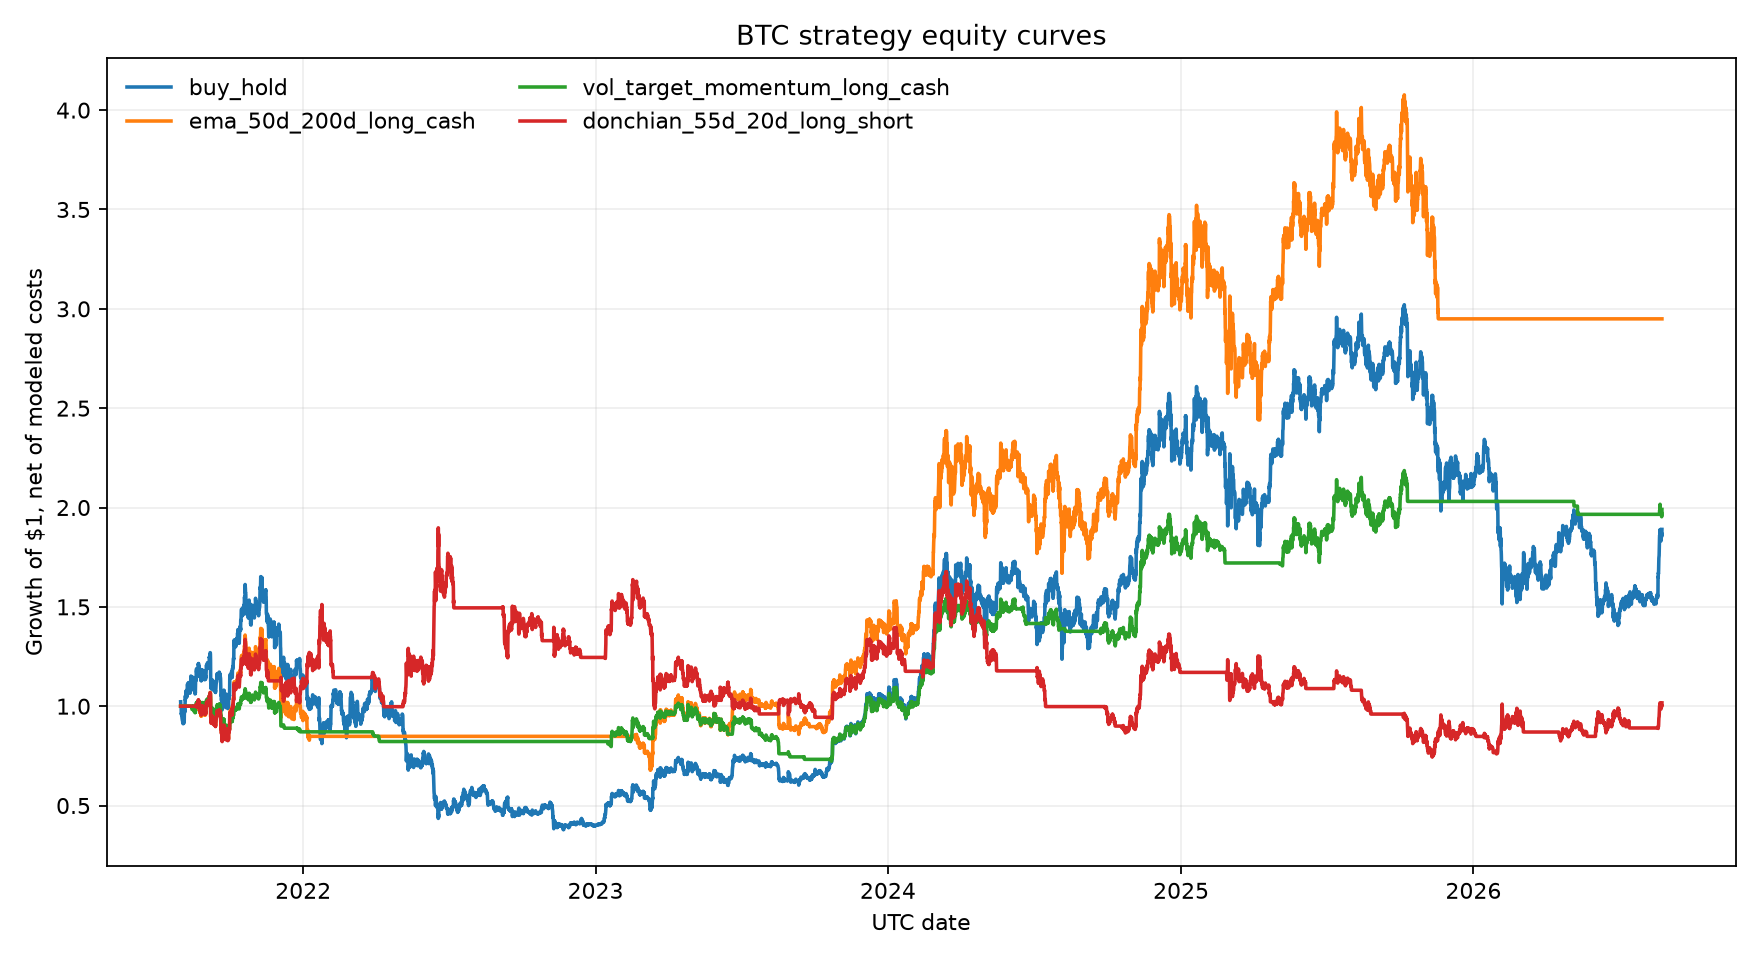

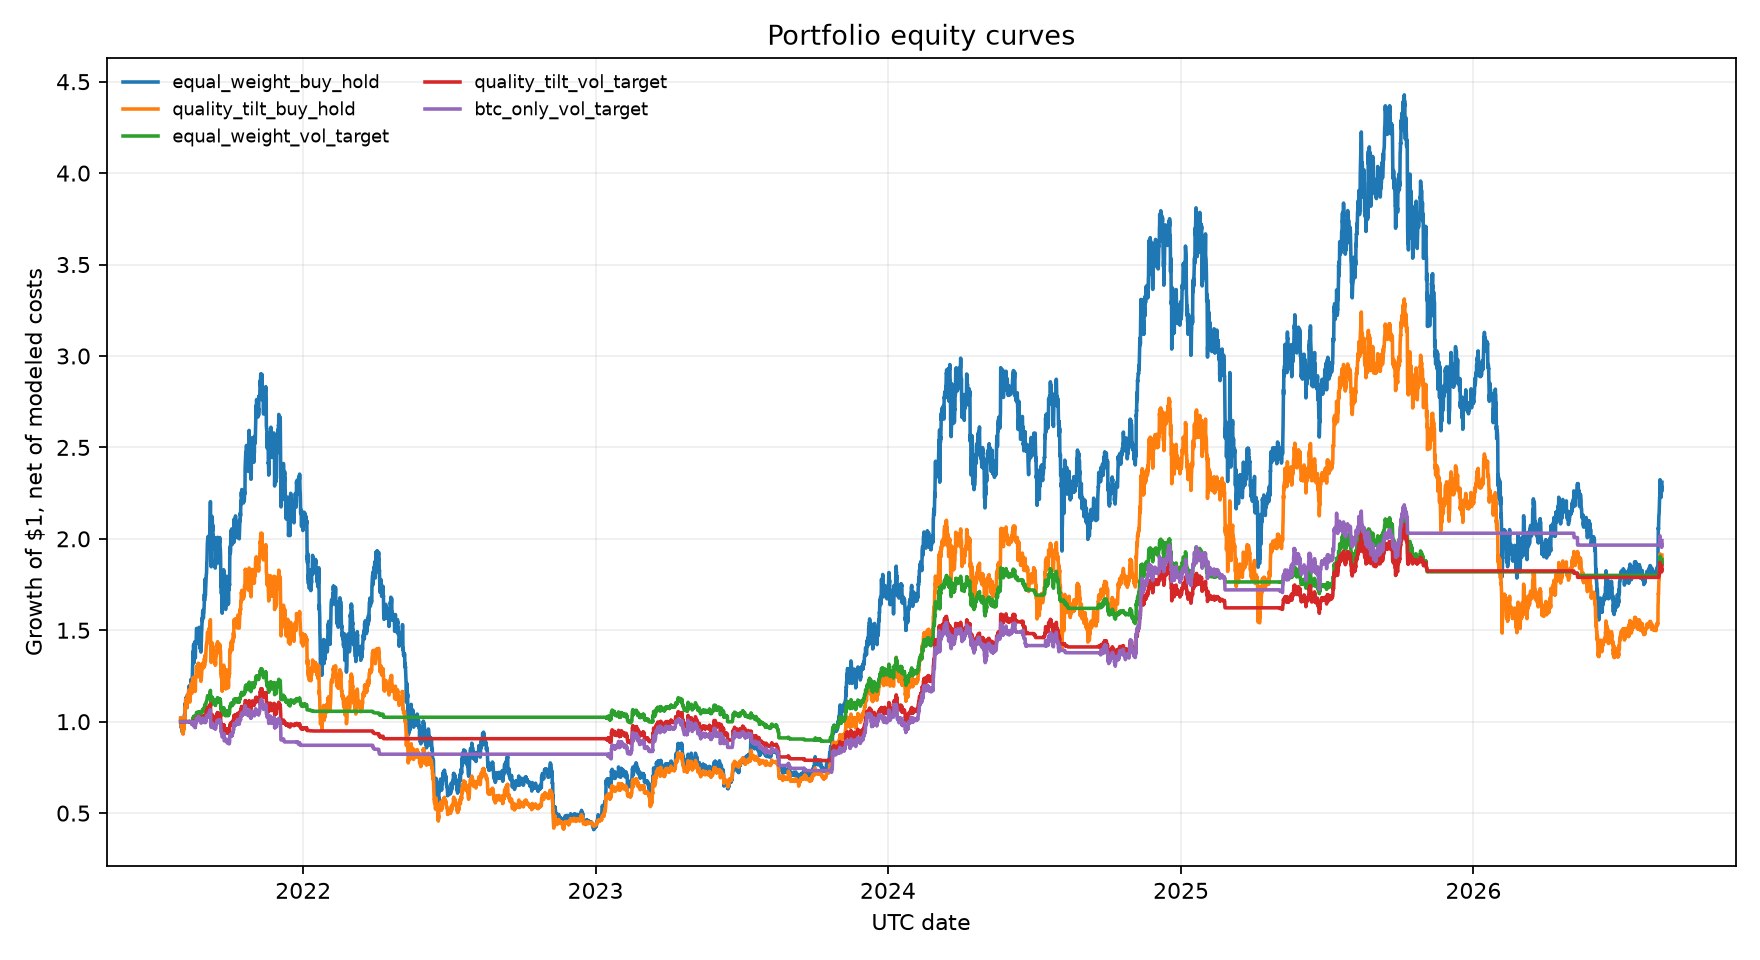

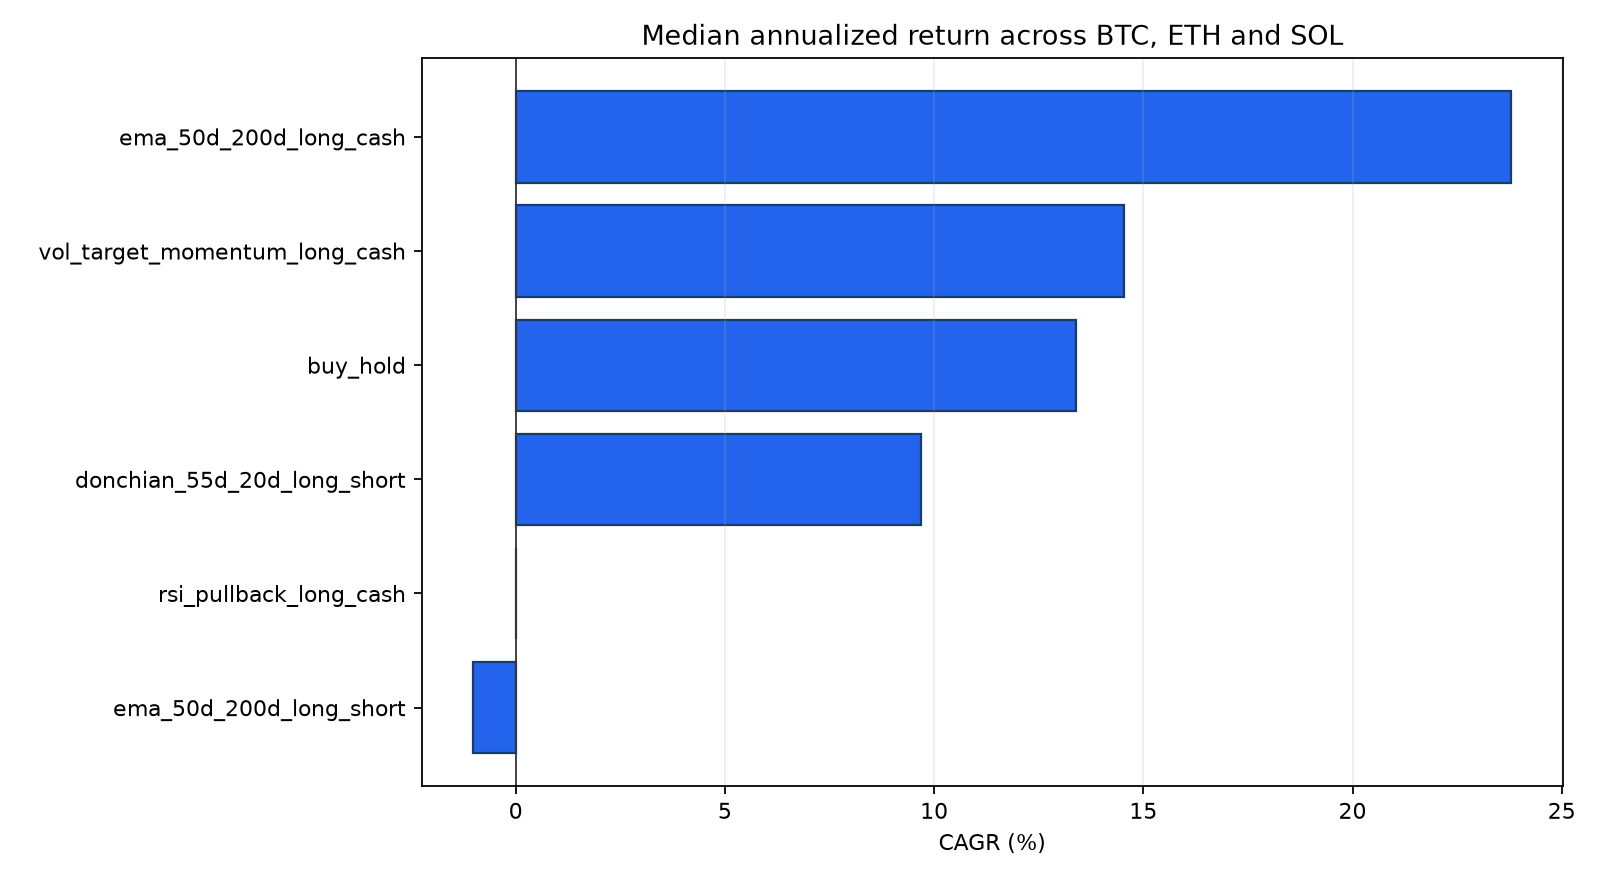

In [4]:
display(Image(filename=str(OUTPUT / 'btc_equity_curves.png')))
display(Image(filename=str(OUTPUT / 'portfolio_equity_curves.png')))
display(Image(filename=str(OUTPUT / 'strategy_cagr_comparison.png')))


## Robustness & Holdout

configs  positive_holdout_pct  median_holdout_pct  worst_holdout_pct  best_holdout_pct
asset family                                                                                                     
BTC   ema_long_cash              9                100.00              104.88              76.55            125.33
      vol_target_momentum       27                100.00               66.68              16.97            125.01
ETH   ema_long_cash              9                 11.11               -8.32             -41.84              1.82
      vol_target_momentum       27                100.00               48.09              26.88            112.58
SOL   ema_long_cash              9                 22.22               -5.91             -17.75             18.43
      vol_target_momentum       27                 40.74               -3.61             -18.12             19.32

### Parameters selected on 2021–2023, evaluated on 2024–current

,asset,family,params,train_return_pct,holdout_return_pct,full_sharpe,full_max_drawdown_pct
0,BTC,ema_long_cash,"fast=30,slow=150",74.04,76.55,0.79,-40.59
1,BTC,vol_target_momentum,"mom=60,slow=150,vol=0.45",71.93,89.37,0.98,-31.57
2,ETH,ema_long_cash,"fast=30,slow=150",64.86,-1.50,0.44,-62.57
3,ETH,vol_target_momentum,"mom=60,slow=150,vol=0.45",46.78,112.58,0.90,-25.65
4,SOL,ema_long_cash,"fast=80,slow=150",985.68,1.11,1.03,-67.51
5,SOL,vol_target_momentum,"mom=120,slow=200,vol=0.45",276.52,19.32,1.15,-30.03


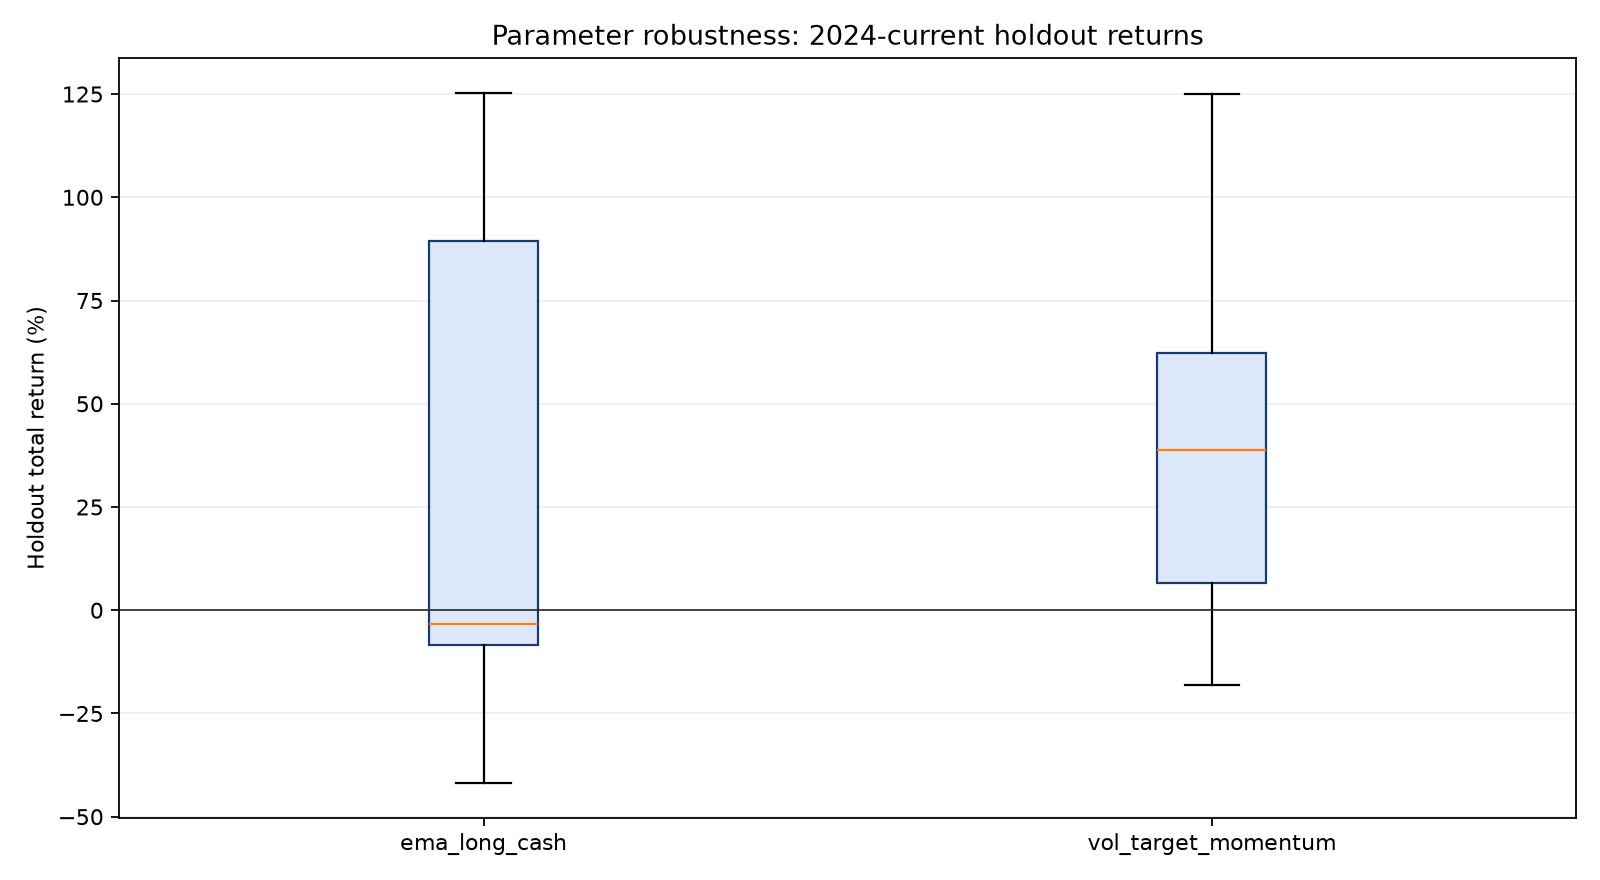

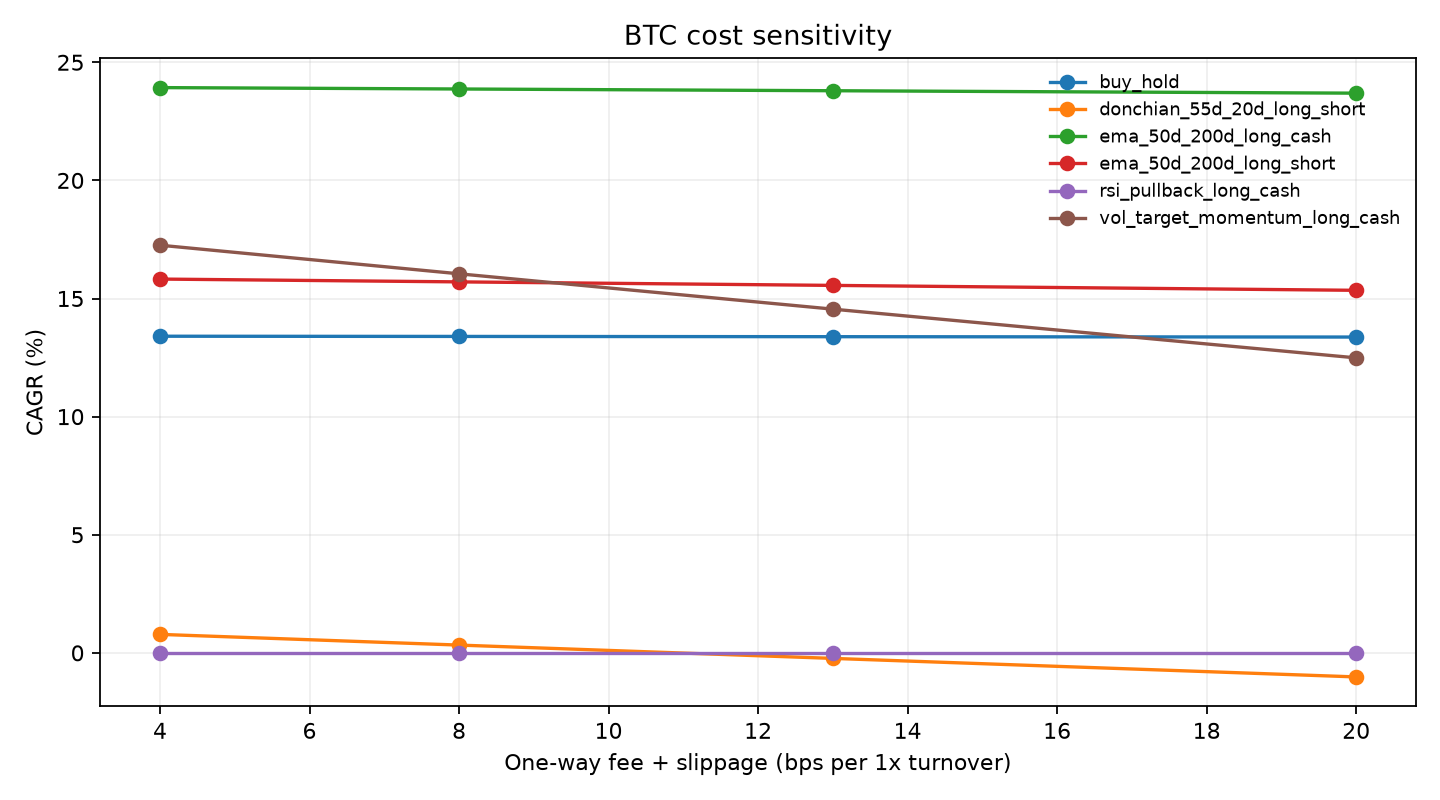

In [5]:
robustness = study['robustness']
robustness_summary = robustness.groupby(['asset','family']).agg(
    configs=('params','size'),
    positive_holdout_pct=('holdout_return_pct', lambda values: (values > 0).mean() * 100),
    median_holdout_pct=('holdout_return_pct','median'),
    worst_holdout_pct=('holdout_return_pct','min'),
    best_holdout_pct=('holdout_return_pct','max'),
).round(2)
display(robustness_summary)
display(Markdown('### Parameters selected on 2021–2023, evaluated on 2024–current'))
display(study['walk_forward'][['asset','family','params','train_return_pct','holdout_return_pct','full_sharpe','full_max_drawdown_pct']].round(2))
display(Image(filename=str(OUTPUT / 'parameter_robustness_holdout.png')))
display(Image(filename=str(OUTPUT / 'btc_cost_sensitivity.png')))


## Validation Report

### Overall Assessment: Share with caveats

### Methodology Review

The independent harness avoids same-bar close execution, includes turnover costs, applies actual funding with correct direction, caps exposure at 1.0x, checks three assets, separates 2021–2023 selection from 2024-current holdout, and tests nearby parameters and costs.

### Issues Found

1. **High — current repository ensemble:** regime-filtered candles are concatenated and backtested as if time were continuous. The resulting return is not decision-grade.
2. **High — current repository fills:** a signal calculated with the current close is filled at that same close. This is optimistic unless a later executable quote is used.
3. **High — current repository funding:** positive funding is subtracted from shorts, although positive funding is paid by longs to shorts.
4. **Medium — this study:** 4-hour OHLCV cannot model order-book depth, partial fills, outages, or gap-dependent slippage.
5. **Medium — this study:** USD-M perpetual OHLCV is used as a price proxy for spot strategies; funding is excluded for those spot-style variants.

### Calculation Spot-Checks

- Source completeness: verified from the generated source-quality table; review row counts, timestamps, duplicates, and null cells after every refresh.
- Execution timing: verified — signal is shifted one bar before returns are applied.
- Funding sign: verified — net return subtracts `position × funding_rate`, so shorts receive positive funding.
- Cost sensitivity: verified across 4, 8, 13, and 20 bps per turnover unit.
- Holdout: verified using 2024-current after parameter selection on 2021–2023.

### Required Caveats

- Backtests estimate behavior under assumptions; they do not prove future profitability.
- Paper trading with live bid/ask and exchange filters is required before any capital allocation.
- Account-level fee tier, taxes, delisting, and exchange/API outage behavior are not included.


## Takeaways

1. **Adopt for paper trading:** long/cash 90-day momentum + 200-day trend filter + 20%–25% volatility target, using BTC/ETH/SOL base weights of 60/30/10 and no leverage.
2. **Keep as benchmark:** 50/200-day long/cash trend. It performed well on BTC but was inconsistent on ETH and SOL and allowed materially deeper drawdowns.
3. **Reject for now:** unrestricted long/short EMA and Donchian futures variants. Cross-asset holdout losses and 79%–91% worst drawdowns are unacceptable for unattended automation.
4. **Reject as inactive:** the tested RSI pullback rule produced no trades, so it provides no evidence of usefulness.
5. **Current regime:** allow partial long exposure, but do not treat the rebound as a confirmed structural bull market until the 50-day trend catches the 200-day trend. Positive funding also favors spot-style exposure over paying perpetual funding for an aggressive long.
